In [4]:
import xarray as xr
import numpy as np
import glob as glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [36]:
from pathlib import Path

p = Path("/home/mduplessis/share/www/data/adt/SEALEVEL_GLO_PHY_L4_NRT_008_046/cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_202506/2026/06/")  # or the full directory path

# Get only files without '(' in the name
nc_without_parens = [
    f for f in p.glob("nrt_global_allsat_phy_l4_*.nc")
    if "(" not in f.name
]

# Sort to ensure time order (if filenames encode time)
nc_without_parens = sorted(nc_without_parens)

ds = xr.open_mfdataset(
    [str(f) for f in nc_without_parens],
    combine="by_coords"
)

/tmp/ipykernel_3229776/4006872905.py:14: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(


In [41]:
ds = ds.sel(latitude=slice(-45, -25), longitude=slice(0, 40))

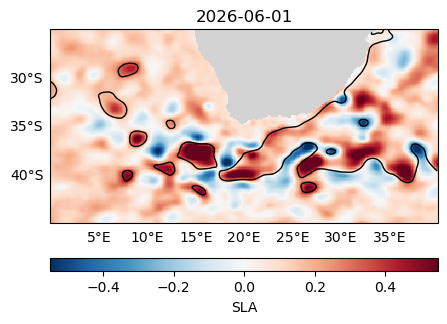

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

da = ds["sla"]
adt = ds["adt"]

lon_name = "longitude" if "longitude" in da.coords else "lon"
lat_name = "latitude" if "latitude" in da.coords else "lat"
time_name = "time"

vmax = float(np.nanpercentile(np.abs(da), 98))
levels = [0.7]

fig = plt.figure(figsize=(5, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([0, 40, -45, -25], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray")

import matplotlib.ticker as mticker

gl = ax.gridlines(draw_labels=True, alpha=0)
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlocator = mticker.FixedLocator(np.arange(0, 45, 5))
gl.ylocator = mticker.FixedLocator(np.arange(-45, -25, 5))

mesh = ax.pcolormesh(
    da[lon_name],
    da[lat_name],
    da.isel({time_name: 0}),
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    shading="auto",
    vmin=-vmax,
    vmax=vmax,
)

contours = ax.contour(
    adt[lon_name],
    adt[lat_name],
    adt.isel({time_name: 0}),
    levels=levels,
    colors="k",
    linewidths=1.0,
    transform=ccrs.PlateCarree(),
)

cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.075, aspect=30)
cbar.set_label("SLA")

title = ax.set_title(str(da[time_name].values[0])[:10])

def update(i):
    global contours

    field = da.isel({time_name: i}).values
    mesh.set_array(field.ravel())

    # remove previous contour set
    contours.remove()

    # draw new contour set
    contours = ax.contour(
        adt[lon_name],
        adt[lat_name],
        adt.isel({time_name: i}),
        levels=levels,
        colors="k",
        linewidths=1.0,
        transform=ccrs.PlateCarree(),
    )

    title.set_text(str(da[time_name].values[i])[:10])
    return [mesh, title, contours]

anim = animation.FuncAnimation(
    fig,
    update,
    frames=da.sizes[time_name],
    interval=300,
    blit=False
)

anim.save("sla_animation.gif", dpi=150, writer="pillow")

In [7]:
adt_data = glob.glob('/home/mduplessis/share/www/data/adt/SEALEVEL_GLO_PHY_L4_NRT_008_046/cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_202506/2026/06/*.nc')

In [9]:
adt_data[0]

'/home/mduplessis/share/www/data/adt/SEALEVEL_GLO_PHY_L4_NRT_008_046/cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_202506/2026/06/nrt_global_allsat_phy_l4_20260601_20260601_(5).nc'